# Introducción a CMT

## Índice<a id="0-índice"></a>
1. [Introducción](#1-intro)
2. [Cargar y visualizar evento](#2-evento)
3. [Mecanismo focal](#3-focal)
4. [Almacenamiento de datos del evento](#4-almacenar)
5. [Ejercicios](#5-ejercicios)

## 1. Introducción <a id="1-intro"></a>

El Tensor de Momento Centroide (CMT) es una representación matemática que describe la fuente sísmica a partir de los promedios espaciales y temporales del momento sísmico. Este método permite estimar los parámetros hipocentrales y los seis elementos independientes del tensor de momento, bajo el supuesto de que la fuente es pequeña respecto a la longitud de onda y duración de la señal analizada.

Además, el CMT incorpora la estimación del centroide de la fuente, es decir, el centro espacial y temporal de liberación del momento sísmico, lo que lo convierte en una herramienta clave para interpretar la geometría de la falla y el mecanismo focal de los terremotos.

[Volver al índice](#0-índice)


## 2. Cargar y visualizar evento <a id="2-evento"></a>

In [54]:
import obspy
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from obspy.core.event import Catalog
from obspy.clients.fdsn import Client as fdsnClient
from obspy.core import UTCDateTime
from obspy import read_events
from obspy.imaging.beachball import beachball

plt.rcParams['figure.figsize'] = 16, 12

In [2]:
event = obspy.read_events("http://www.ldeo.columbia.edu/~gcmt/projects/CMT/catalog/NEW_QUICK/"
                         "E202109080147A.ndk")

In [10]:
ev=event[0]

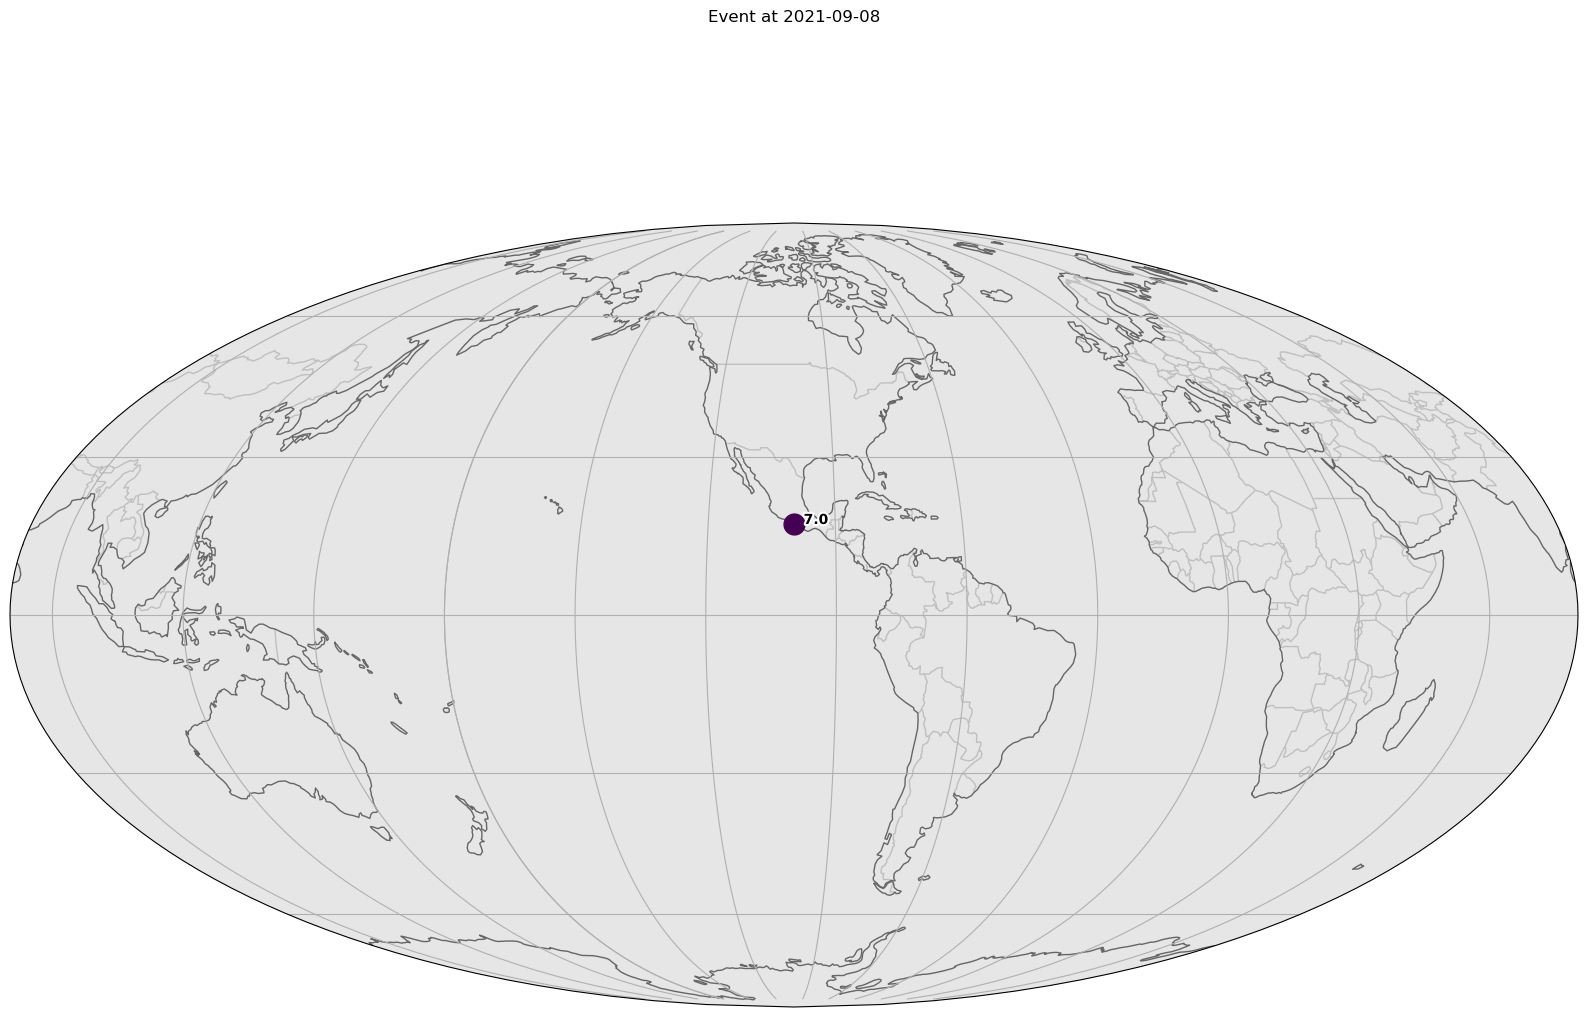

In [11]:
event.plot();

[Volver al índice](#0-índice)

## 3. Mecanismo focal <a id="3-focal"></a>
Los mecanismos focales son una representación de la geometría de una falla y cómo se mueve ésta durante un sismo.

![Mecanismos focales](mecfoc-2.jpg)


In [12]:
#El tensor de momento contiene información del tamaño del sismo así como de los parámetros geométricos de la falla responsable
mt = ev.focal_mechanisms[0].moment_tensor.tensor
print("Tensor de Momento (en dina·cm):")
print(f"Mrr: {mt.m_rr}, Mtt: {mt.m_tt}, Mpp: {mt.m_pp}")
print(f"Mrt: {mt.m_rt}, Mrp: {mt.m_rp}, Mtp: {mt.m_tp}")


Tensor de Momento (en dina·cm):
Mrr: 2.29e+19, Mtt: -2.13e+19, Mpp: -1.62e+18
Mrt: 2.41e+19, Mrp: -1.43e+19, Mtp: 6.84e+18


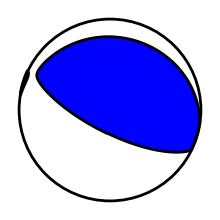

In [15]:
mt_array = [mt.m_rr, mt.m_tt, mt.m_pp, mt.m_rt, mt.m_rp, mt.m_tp]
beachball(mt_array, size=200, linewidth=2);

### Planos Nodales
Las polaridades de primer arribo generan cuatro cuadrantes: dos de compresión y dos de dilatación.

Estos cuadrantes están delimitados por dos planos ortogonales, conocidos como **planos nodales**.

![Planos nodales](planonodal.jpg)

In [24]:
fm = ev.focal_mechanisms[0]

print("Plano nodal 1:")
print("Strike:", fm.nodal_planes.nodal_plane_1.strike)
print("Dip:", fm.nodal_planes.nodal_plane_1.dip)
print("Rake:", fm.nodal_planes.nodal_plane_1.rake)

print("\nPlano nodal 2:")
print("Strike:", fm.nodal_planes.nodal_plane_2.strike)
print("Dip:", fm.nodal_planes.nodal_plane_2.dip)
print("Rake:", fm.nodal_planes.nodal_plane_2.rake)


Plano nodal 1:
Strike: 277.0
Dip: 21.0
Rake: 71.0

Plano nodal 2:
Strike: 118.0
Dip: 70.0
Rake: 97.0


### Momento escalar
Es una cantidad proporcional al área de ruptura (i.e., al tamaño de la falla geológica que rompió) y al deslizamiento que ocurra en la falla.

In [19]:
ev.focal_mechanisms[0].moment_tensor.scalar_moment

3.636e+19

[Volver al índice](#0-índice)

## 4. Almacenamiento de datos del evento <a id="4-almacenar"></a> 

In [22]:
data = {
    "Latitud": [ev.preferred_origin().latitude],
    "Longitud": [ev.preferred_origin().longitude],
    "Profundidad (km)": [ev.preferred_origin().depth / 1000],
    "Magnitud": [ev.preferred_magnitude().mag],
    "Momento escalar": [fm.moment_tensor.scalar_moment],
    "Strike1": [fm.nodal_planes.nodal_plane_1.strike],
    "Dip1": [fm.nodal_planes.nodal_plane_1.dip],
    "Rake1": [fm.nodal_planes.nodal_plane_1.rake]
}

df = pd.DataFrame(data)
df


,Latitud,Longitud,Profundidad (km),Magnitud,Momento escalar,Strike1,Dip1,Rake1
0,17.03,-99.74,20.7,6.97,3.636000e+19,277.0,21.0,71.0


In [ ]:
dat.to_csv("CMT.csv")

[Volver al índice](#0-índice)

## 5. Ejercicios <a id="5-ejercicios"></a> 

### Evento sísmico: México 19/09/2017

En este ejercicio vamos a trabajar con el catálogo de septiembre de 2017 y extraer el **evento sísmico de magnitud 7.1 en México**

In [45]:
#catálogo de septiempre de 2017
catalog = obspy.read_events("https://www.ldeo.columbia.edu/~gcmt/projects/CMT/catalog/NEW_MONTHLY/2017/sep17.ndk")

In [46]:
catalog

192 Event(s) in Catalog:
2017-09-01T02:38:15.500000Z | +32.240,  +82.740 | 4.98 Mwc
2017-09-01T03:47:36.500000Z | -11.470, +113.090 | 4.8  Mwc
...
2017-09-30T20:14:45.200000Z | +21.360, +143.850 | 4.88 Mwc
2017-09-30T23:15:33.800000Z |  +4.110, +128.490 | 5.6  Mwc
To see all events call 'print(CatalogObject.__str__(print_all=True))'

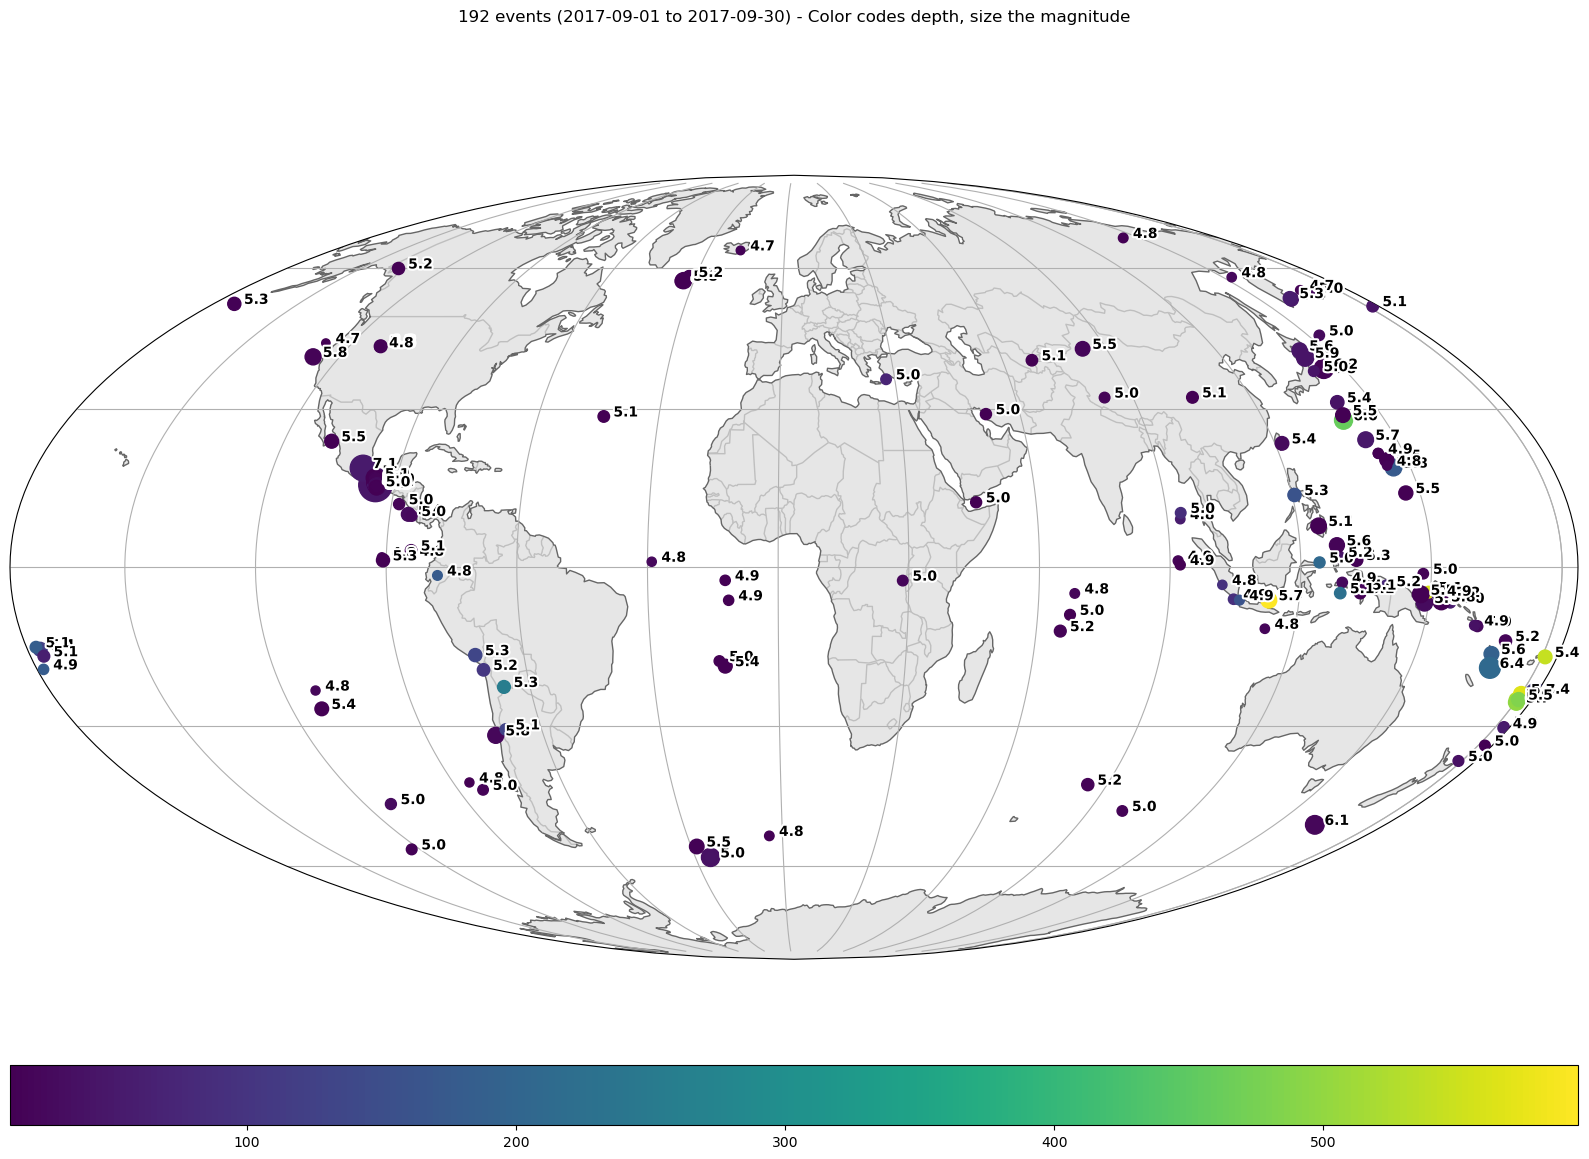

In [53]:
catalog.plot();

In [42]:
#fecha del evento y ubicación
fecha_evento = UTCDateTime("2017-09-19T18:14:00") 
lat_min, lat_max = 14, 21
lon_min, lon_max = -100, -95

In [47]:
#buscar el evento en el catálogo
eventos_filtrados = [ev for ev in catalog 
                     if abs(ev.origins[0].time - fecha_evento) < 60  # ±60 segundos
                     and lat_min <= ev.origins[0].latitude <= lat_max
                     and lon_min <= ev.origins[0].longitude <= lon_max]

In [48]:
eventos_filtrados

[Event:	2017-09-19T18:14:47.200000Z | +18.590,  -98.630 | 7.14 Mwc

	                  resource_id: ResourceIdentifier(id="smi:local/ndk/C201709191814A/event")
	                   event_type: 'earthquake'
	         event_type_certainty: 'known'
	          preferred_origin_id: ResourceIdentifier(id="smi:local/ndk/C201709191814A/origin#cmtorigin")
	       preferred_magnitude_id: ResourceIdentifier(id="smi:local/ndk/C201709191814A/magnitude#moment_mag")
	 preferred_focal_mechanism_id: ResourceIdentifier(id="smi:local/ndk/C201709191814A/focal_mechanism")
	                         ---------
	           event_descriptions: 2 Elements
	             focal_mechanisms: 1 Elements
	                      origins: 2 Elements
	                   magnitudes: 3 Elements]

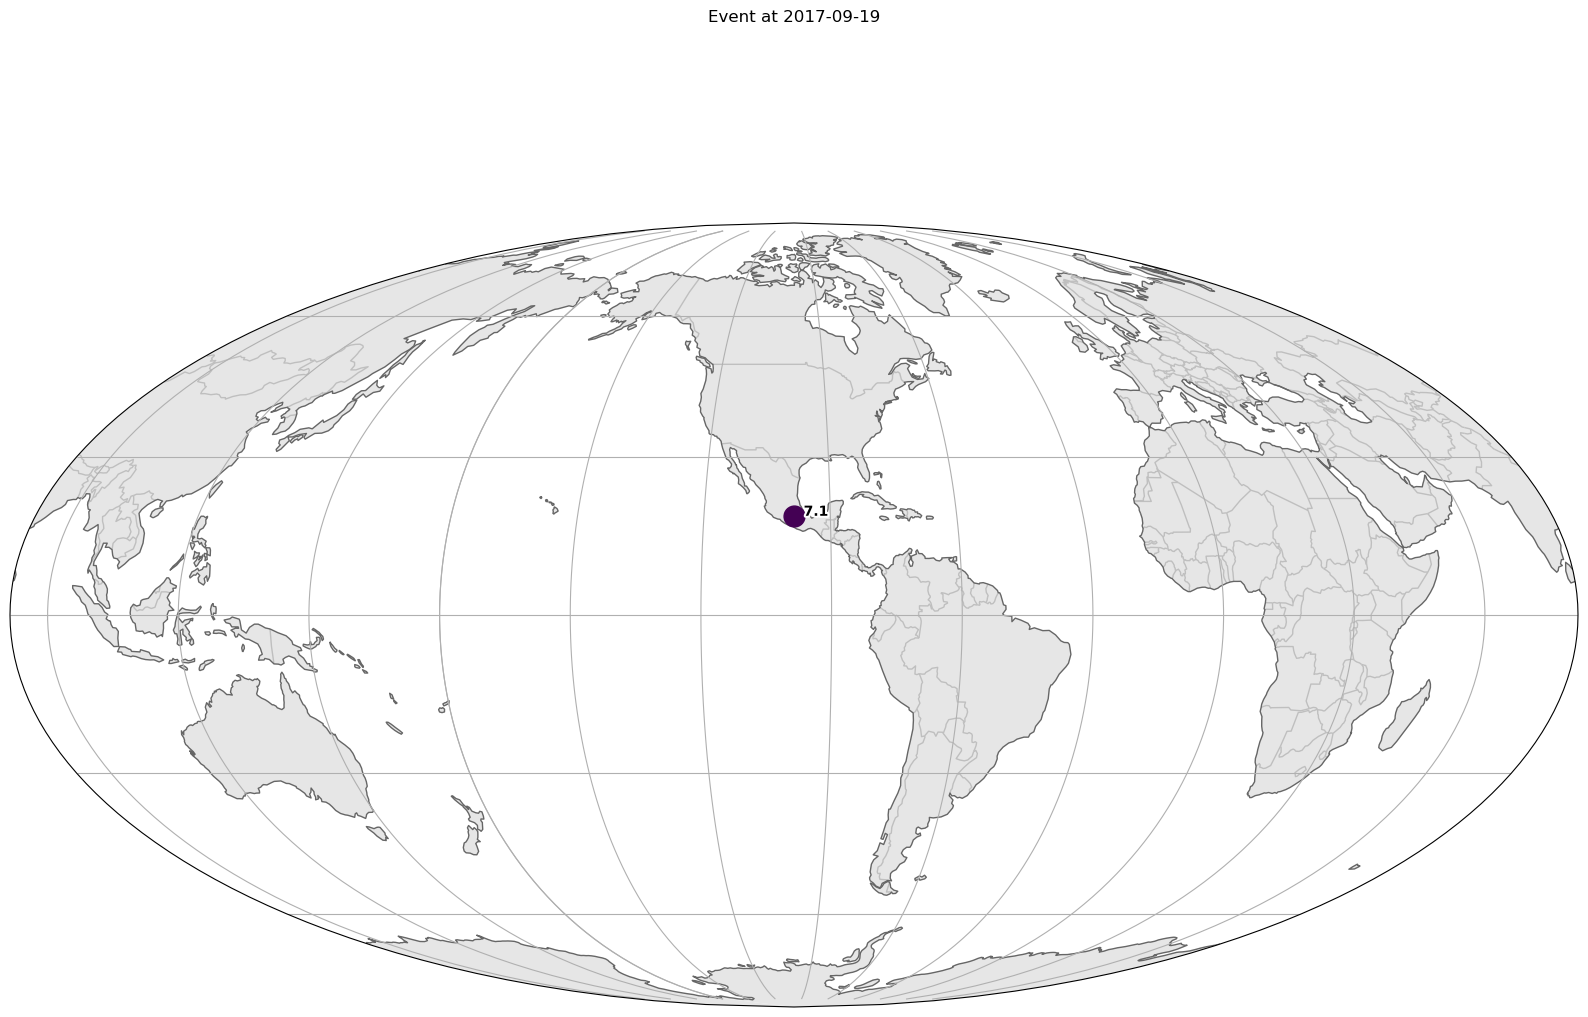

In [56]:
#visualizar el evento
cat_filtrado = Catalog(eventos_filtrados)
cat_filtrado.plot();

Ya que tenemos el evento, **grafica el mecanismo focal (pelota de playa) y calcula el momento escalar del sismo**, finalmente, guarda los datos de este en un csv:

## Referencias

Servicio Sismológico Nacional [SSN]. (s. f.). Catálogo de sismos. Universidad Nacional Autónoma de México. http://www2.ssn.unam.mx:8080/catalogo/

Global Centroid-Moment Tensor (GCMT) Project. (n.d.). Quick CMT catalog. Lamont-Doherty Earth Observatory, Columbia University. https://www.ldeo.columbia.edu/~gcmt/projects/CMT/catalog/NEW_QUICK/

ScienceDirect. (s.f.) Tensor de momento centroide. Recuperado de: https://www-sciencedirect-com.translate.goog/topics/earth-and-planetary-sciences/centroid-moment-tensor?_x_tr_sl=en&_x_tr_tl=es&_x_tr_hl=es&_x_tr_pto=tc

Instituto Geofísico [EPN]. (s.f.). Mecanismos Focales. Recuperado de: https://www.igepn.edu.ec/mecanismos-focales

Universidad Nacional de La Plata [UNLP]. (s.f.). Mecanismos focales. Recuperado de: http://sismologia.fcaglp.unlp.edu.ar/practicas/lineamientos_TP16.pdf#page=2.00

Villamizar, M., & Cabrera Zambrano, F. (2022). Cálculo y análisis de los mecanismos focales del Nido sísmico de Bucaramanga a partir de registros de la red sismológica nacional. Recuperado de: https://www.researchgate.net/figure/Figura-3-Planos-nodales-y-cuadrantes-para-las-zonas-de-compresion-y-extension-Imagen_fig3_372601819

Instituto Geográfico Nacional. (s. f.). Determinación automática del Tensor Momento Sísmico (TMS) en el Instituto Geográfico
Nacional. Recuperado de: https://www.ign.es/web/resources/docs/IGNCnig/SIS-Tensor-Momento-Sismico.pdf

Servicio Sismológico Nacional. (s.f.). Magnitud de un sismo. Recuperado de: http://www.ssn.unam.mx/jsp/reportesEspeciales/Magnitud-de-un-sismo.pdf